# DNN HW 1


## Handle imports & installs

In [1]:
!pip install pandas clusterfun scikit-learn


[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install -q clusterfun umap-learn


[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import math
import sys

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import plotly.graph_objects as go
from torch import Tensor
from torchvision import datasets, transforms
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import umap
import clusterfun as clt
from PIL import Image
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# Allow custom (non-ipywidget) widgets.
import umap
if "google.colab" in sys.modules:
    from google.colab import output

    output.enable_custom_widget_manager()

# For reproducibility.
torch.manual_seed(1)

/home/gemlorg/projects/studies/fifth-year/DNN/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prepare the Torch dataframe

In [ ]:
from pathlib import Path
from typing import Callable
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets.vision import VisionDataset
from torchvision import transforms
import pandas as pd
import os
from PIL import Image

CSV_LABELS_FILENAME = "labels.csv"
IMG_COL_NAME = "name"
TARGET_COL_NAMES = ["squares","circles","up","right","down","left"]
TRAIN_DATASET_LEN = 9000
TOTAL_DATASET_LEN = 10000

class IMGDataset(VisionDataset):
    def __init__(
        self,
        root: str | Path = "./data",
        train: bool | None = True,
        transform: Callable | None = None,
        target_transform: Callable | None = None,
    ) -> None:
        super().__init__(root, transform=transform, target_transform=target_transform)
        self.train = train  # training set or test set
        
        labels_df = pd.read_csv(os.path.join(root, CSV_LABELS_FILENAME))
        assert len(labels_df) == TOTAL_DATASET_LEN, f"Expected {TOTAL_DATASET_LEN} samples, got {len(labels_df)}"

        if self.train is not None:
            if self.train:
                labels_df = labels_df.iloc[:TRAIN_DATASET_LEN]
            else:
                labels_df = labels_df.iloc[TRAIN_DATASET_LEN:]
        
        self.data, self.targets_raw = self._load_data(labels_df) 
        self.labels = labels_df
        
        
    def _load_data(self, labels_df: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor]:
        imgs = [] 
        for img_path in labels_df[IMG_COL_NAME]:
            img = Image.open(os.path.join(self.root, img_path)).convert("L")
            tensor_img = transforms.ToTensor()(img)  # [1, H, W], float32 in [0,1]
            imgs.append(tensor_img)        
        # convert images to tensor
        data = torch.stack(imgs, dim=0)  # [N, 1, H, W]
        print("Preloaded data shape:", data.shape)
        targets = torch.tensor(labels_df[TARGET_COL_NAMES].values, dtype=torch.float32)  # [N, 6]

        return data, targets
    def __len__(self) -> int:
            return self.data.shape[0]

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        img = self.data[index]              # [1, 28, 28]
        target = self.targets_raw[index]    # [num_targets], float32

        # optional image transform (must work on tensors)
        if self.transform is not None:
            img = self.transform(img)

        # optional target transform: e.g. create (class_id, counts)
        if self.target_transform is not None:
            target = self.target_transform(target)

        return img, target

    def repr_item(self, index: int) -> None:
        """
        Debug / visualization helper:
        - shows the image
        - prints its labels / classes
        Uses __getitem__, so it respects transforms / target_transforms.
        """
        import matplotlib.pyplot as plt

        img, target = self[index]  # go through the normal pipeline

        img_np = img.squeeze(0).detach().cpu().numpy()  # [H, W]
        plt.imshow(img_np)
        plt.axis("off")

        # Build a nice label string
        base_info = f"index={index}, targets: "

        label_str = base_info + "\n"
        for name, label in zip (TARGET_COL_NAMES, target):
            label_str += f"{name}: {label.item():.0f} "

        print(label_str)
        plt.title("Sample visualization")
        plt.show()

    def get_labels(self) -> pd.DataFrame:
        """
        Returns the labels dataframe.
        """
        return self.labels


In [5]:
dataset = IMGDataset(train=None)
dataset

Preloaded data shape: torch.Size([10000, 1, 28, 28])


Dataset IMGDataset
    Number of datapoints: 10000
    Root location: ./data

Verify that the images were loaded correctly:

index=1, targets: 
squares: 0 circles: 0 up: 0 right: 5 down: 0 left: 5 


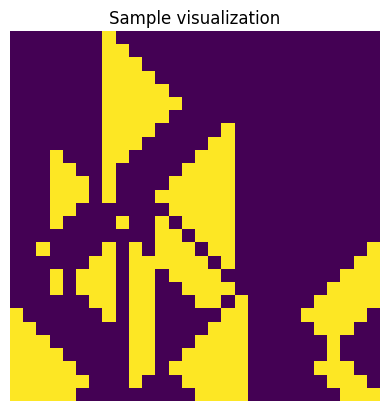

In [6]:
dataset.repr_item(1)

## Data Analysis

We focus on the labels df, verify the distribution of classes etc. 


In [7]:
labels_df = dataset.get_labels()

In [8]:
labels_df.describe()

,squares,circles,up,right,down,left
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.65740,1.714900,1.653000,1.677000,1.685700,1.612000
std,2.62909,2.656073,2.619557,2.627539,2.641101,2.574979
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
max,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000


In [9]:
# assert 1 not in df 
for col in labels_df.columns:
    assert 1 not in labels_df[col].values

It seems the max value for each col is 8, therefore there can be at most 6 * 5 / 2 * 7 = 105 classes represented, not 135 as described in the assignment 

In [10]:
def get_configuration(row: dict) -> int: 
    #get names of columns that are not 0 
    selected_names = list(filter(lambda x: row[x] > 0, TARGET_COL_NAMES))
    # assert there are two of them 
    assert len(selected_names) == 2, f"Expected 2 non-zero columns, got {row}, selected_names={selected_names}"
    # get their indices 
    indices = list(map(lambda x: TARGET_COL_NAMES.index(x), selected_names))
    # sort the indices 
    indices.sort()
    # calculate the idx 
    idx = 0
    indices = sorted(TARGET_COL_NAMES.index(name) for name in selected_names)
    a, b = indices  # 0 <= a < b < n
    n = len(TARGET_COL_NAMES)
    pair_index = a * (2 * n - a - 1) // 2 + (b - a - 1)  # in [0, 14] for n=6
    idx += pair_index * 7
    idx += row[TARGET_COL_NAMES[indices[0]]] - 2
    return idx 

# Unit test for get_configuration
def make_row(i, j, v):
    """
    Build a row dict with exactly two non-zero columns:
    - column i has count v (2..9)
    - column j has count 2
    """
    row = {name: 0 for name in TARGET_COL_NAMES}
    row[TARGET_COL_NAMES[i]] = v
    row[TARGET_COL_NAMES[j]] = 10 - v
    return row

def test_get_configuration_120_unique_classes():
    seen = set()
    count = 0

    for i in range(len(TARGET_COL_NAMES)):
        for j in range(i + 1, len(TARGET_COL_NAMES)):
            for v in range(2, 9):  # 2..8 (7 values)
                count += 1
                row = make_row(i, j, v)
                cfg = get_configuration(row)

                # config index should live in [0, 120)
                assert 0 <= cfg < 120
                seen.add(cfg)

    # 6 choose 2 = 15 pairs, 15 * 7 = 105
    assert len(seen) == 105, f"Expected 105 unique configurations, got {len(seen)}"
    assert count == 105
test_get_configuration_120_unique_classes()
labels_df['configuration'] = labels_df.apply(get_configuration, axis=1)


array([[<Axes: title={'center': 'configuration'}>]], dtype=object)

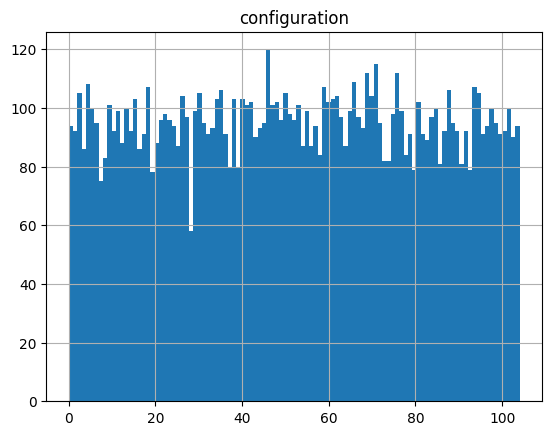

In [11]:
labels_df[['configuration']].hist(bins=105)

In [12]:
config_dist = labels_df["configuration"].value_counts().sort_index()
config_dist.describe()

count    105.000000
mean      95.238095
std        9.364955
min       58.000000
25%       91.000000
50%       95.000000
75%      102.000000
max      120.000000
Name: count, dtype: float64

All of the classes seem to be pretty well represented (except maybe for one, but it still doesn't seem like an issue). Here we've checked for the entire dataset, assuming the train/test split required by the assignment definition was done randomly, the same should hold for the train/test datasets. 

The plotted embeddings are not included in the notebook as they don't really tell any info.
    

## Model setup

In [60]:
from __future__ import annotations
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch import nn
import torch.nn.functional as F

from dataclasses import dataclass
from typing import Literal

import torch
from torch import nn, Tensor
import torch.nn.functional as F

class GSNMultiTaskNet(nn.Module):
    """
    Multitask model for GSN:
      - Classification: 135 config classes -> log-probs
      - Regression: 6 shape counts

    Input:  x  [B, 1, 28, 28]
    Output: (log_probs, counts)
      - log_probs: [B, 135]
      - counts:    [B, 6]
    """

    def __init__(self, num_classes: int = 105, num_counts: int = 6, dropout_p: float = 0.3):
        super().__init__()

        # ---------- fixed backbone (do NOT change) ----------
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(64 * 28 * 28, 256), nn.ReLU()
        )

        # ---------- classification head: 135-way log-probs ----------
        self.head_cls = nn.Sequential(
            nn.Linear(256, num_classes)
            # nn.Dropout(dropout_p),
            # nn.Linear(128, 128), nn.ReLU(),
            # nn.Linear(128, num_classes)
            # log_softmax will be applied in forward()
        )

        # ---------- regression head: 6 counts ----------
        self.head_cnt = nn.Sequential(
            nn.Linear(256, num_classes),
            # nn.ReLU(),
            # nn.Linear(64,  64), nn.ReLU(),
            # nn.Linear(64, num_counts)
        )

    def forward(self, x: torch.Tensor):
        """
        x: [B, 1, 28, 28]
        returns:
          log_probs: [B, num_classes]
          counts:    [B, num_counts]
        """
        features = self.backbone(x)              # [B, 256]

        logits = self.head_cls(features)         # [B, 105]
        log_probs = F.log_softmax(logits, dim=1)

        counts = self.head_cnt(features)         # [B, 6]

        return log_probs, counts




In [56]:

from dataclasses import dataclass
from typing import Dict
@dataclass
class MultiTaskLossOutput:
    """Convenient container for logging the components of the loss."""
    total: Tensor
    cls: Tensor
    reg: Tensor


@dataclass
class ClassificationMetrics:
    """135-way classification metrics."""
    top1_acc: float                    # Top-1 accuracy over all configs
    macro_f1: float                    # Macro F1 over 135 classes
    per_pair_acc: Dict[str, float]     # Accuracy aggregated by unordered shape pair


@dataclass
class RegressionMetrics:
    """6-D count regression metrics."""
    rmse_overall: float                # RMSE averaged over all 6 dims
    mae_overall: float                 # MAE averaged over all 6 dims
    rmse_per_dim: Dict[str, float]     # RMSE per shape (squares, circles, ...)
    mae_per_dim: Dict[str, float]      # MAE per shape (squares, circles, ...)


@dataclass
class MultiTaskMetrics:
    """Top-level container returned by `MultiTaskTrainer.evaluate`."""
    loss_total: float
    loss_cls: float
    loss_reg: float
    classification: ClassificationMetrics
    regression: RegressionMetrics


class GSNMultiTaskLoss(nn.Module):
    """
    Multitask loss for Graph ShapeNet-style counting.

    - Classification head predicts a configuration over shape/count patterns.
    - Regression head predicts the 6 raw counts.
    - The ground-truth labels are ONLY the 6D counts; configuration IDs are
      computed internally from those counts.

    Args
    ----
    lambda_cnt:
        Weight for the regression (count) loss term.
    reduction:
        Reduction applied to individual NLL and SmoothL1 losses.
        One of {"mean", "sum", "none"}.
    values_min:
        Minimum non-zero count value used in the configuration encoding.
    values_max:
        Maximum non-zero count value used in the configuration encoding.
    """
    def __init__(
        self,
        lambda_cnt: float = 1.0,
        reduction: Literal["mean", "sum", "none"] = "mean",
        values_min: int = 2,
        values_max: int = 8,
    ) -> None:
        super().__init__()
        self.lambda_cnt = float(lambda_cnt)
        self.reduction = reduction
        self.values_min = int(values_min)
        self.values_max = int(values_max)

        self._cls_loss = nn.NLLLoss(reduction=reduction)
        self._reg_loss = nn.SmoothL1Loss(reduction=reduction)

    def forward(
        self,
        cls_logits: Tensor,   # [B, num_configs]
        counts_pred: Tensor,  # [B, 6]
        count_targets: Tensor # [B, 6]
    ) -> MultiTaskLossOutput:
        """
        Compute multitask loss.

        Args:
            cls_logits:
                Raw (un-normalized) scores from classification head, shape [B, C].
            counts_pred:
                Predicted counts from regression head, shape [B, 6].
            count_targets:
                Ground-truth counts, shape [B, 6].

        Returns:
            MultiTaskLossOutput with total / cls / reg components.
            You typically do: `loss = criterion(...).total`
        """
        if count_targets.ndim != 2 or count_targets.size(1) != 6:
            raise ValueError(f"Expected count_targets of shape [B, 6], got {tuple(count_targets.shape)}")

        # 1) Compute configuration IDs from counts.
        config_ids = counts_to_config_ids(
            count_targets,
            values_min=self.values_min,
            values_max=self.values_max,
        )  # [B]

        # 2) Classification loss: NLL over log-softmaxed logits.
        log_probs = F.log_softmax(cls_logits, dim=1)  # [B, C]
        loss_cls = self._cls_loss(log_probs, config_ids)

        # 3) Regression loss over the raw counts.
        loss_reg = self._reg_loss(counts_pred, count_targets)

        # 4) Total multitask loss.
        loss_total = loss_cls + self.lambda_cnt * loss_reg

        return MultiTaskLossOutput(total=loss_total, cls=loss_cls, reg=loss_reg)

def counts_to_config_ids(
    count_targets: Tensor,
    *,
    values_min: int = 2,
    values_max: int = 8,
) -> Tensor:
    """
    Map per-sample 6D counts -> scalar configuration IDs.

    Args
    ----
    count_targets:
        Tensor of shape [B, 6].
        Expected: exactly two entries per row are > 0 and equal,
        and their value is in [values_min, values_max].

    Returns
    -------
    config_ids:
        Long tensor of shape [B] with configuration IDs.
    """
    if count_targets.ndim != 2 or count_targets.size(1) != 6:
        raise ValueError(f"Expected count_targets of shape [B, 6], got {tuple(count_targets.shape)}")

    counts = count_targets.to(torch.float32)
    B, n = counts.shape  # n should be 6

    # top-2 non-zero entries (we assume ground truth is discrete & well-formed)
    values, indices = torch.topk(counts, k=2, dim=1)  # [B, 2], [B, 2]

    # unordered pair (a, b) with a < b
    a = torch.min(indices[:, 0], indices[:, 1])
    b = torch.max(indices[:, 0], indices[:, 1])

    # combinatorial index for 0 ≤ a < b < n
    pair_index = a * (2 * n - a - 1) // 2 + (b - a - 1)  # [B]

    # value v is the positive count (both active entries are equal)
    v = values[:, 0].round().to(torch.long)  # [B]

    num_values = values_max - values_min + 1
    value_offset = v - values_min  # [B]

    valid = (value_offset >= 0) & (value_offset < num_values)
    if not torch.all(valid):
        bad_vals = v[~valid].tolist()
        raise ValueError(
            f"Found count values outside [{values_min}, {values_max}] in targets: {bad_vals}"
        )

    config_ids = pair_index * num_values + value_offset
    return config_ids.to(dtype=torch.long, device=count_targets.device)


In [57]:
class MultiTaskTrainer:
    def __init__(
        self,
        model: nn.Module,
        trainloader: DataLoader,
        testloader: DataLoader,
        device: torch.device ,
        lambda_cnt: float = 1.0,
        values_min: int = 2,
        values_max: int = 8,
    ) -> None:
        self.device = torch.device(device)
        self.model = model.to(self.device)
        self.trainloader = trainloader
        self.testloader = testloader

        self.criterion = GSNMultiTaskLoss(
            lambda_cnt=lambda_cnt,
            reduction="mean",
            values_min=values_min,
            values_max=values_max,
        )
        self.lambda_cnt = float(lambda_cnt)
        self.values_min = values_min
        self.values_max = values_max

    def train(
        self,
        epochs: int = 100,
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        log_freq: int = 50,
    ) -> None:
        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay,

        )

        for epoch in range(epochs):
            self.model.train()
            running_loss = 0.0

            for batch_idx, (images, count_targets) in enumerate(self.trainloader):
                images = images.to(self.device)
                count_targets = count_targets.to(self.device)

                optimizer.zero_grad()
                cls_logits, counts_pred = self.model(images)  # model must return (cls_logits, counts_pred)

                loss = self.criterion(cls_logits, counts_pred, count_targets).total
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

                if (batch_idx + 1) % log_freq == 0:
                    avg_loss = running_loss / log_freq
                    print(
                        f"epoch {epoch + 1:>4}, "
                        f"batch {batch_idx + 1:>5}, "
                        f"loss {avg_loss:.3f}"
                    )
                    running_loss = 0.0

            # end of epoch: evaluate on test set
            metrics = self.evaluate()
            print(f"epoch {epoch + 1:>4} evaluation: ")
            print(f"loss_total: {metrics.loss_total:.4f}, ")
            print(f"accuracy: {metrics.classification.top1_acc:.4f}, ")
            print()
    @torch.no_grad()
    def evaluate(self) -> MultiTaskMetrics:
        """
        Evaluate on the held-out testloader and return MultiTaskMetrics.

        Classification:
            - Top-1 accuracy (135-way)
            - Macro F1-score (135-way)
            - Per-pair accuracy aggregated by unordered shape pair

        Regression (6-D counts):
            - RMSE per class (dimension) and overall
            - MAE per class (dimension) and overall
        """
        from sklearn.metrics import f1_score  # local import to keep dependencies scoped

        self.model.eval()

        num_dims = 6  # squares, circles, up, right, down, left
        num_values = self.values_max - self.values_min + 1
        num_pairs = num_dims * (num_dims - 1) // 2  # C(6, 2) = 15

        # --------- Accumulators for losses ----------
        total_samples = 0
        sum_loss_cls = 0.0
        sum_loss_reg = 0.0

        # --------- Classification metrics ----------
        correct_top1 = 0
        all_true = []  # list of 1D tensors with true config IDs
        all_pred = []  # list of 1D tensors with predicted config IDs

        correct_per_pair = torch.zeros(num_pairs, dtype=torch.long)
        count_per_pair = torch.zeros(num_pairs, dtype=torch.long)

        # --------- Regression metrics ----------
        sum_sq_err = torch.zeros(num_dims, device=self.device)   # for RMSE
        sum_abs_err = torch.zeros(num_dims, device=self.device)  # for MAE

        for images, count_targets in self.testloader:
            images = images.to(self.device)
            count_targets = count_targets.to(self.device)

            cls_logits, counts_pred = self.model(images)  # [B, C], [B, 6]
            batch_size = images.size(0)
            total_samples += batch_size

            # ----- Losses -----
            # Use the same criterion as during training.
            loss_out = self.criterion(cls_logits, counts_pred, count_targets)
            sum_loss_cls += float(loss_out.cls.item()) * batch_size
            sum_loss_reg += float(loss_out.reg.item()) * batch_size

            # ----- True configuration IDs from counts -----
            config_ids = counts_to_config_ids(
                count_targets,
                values_min=self.values_min,
                values_max=self.values_max,
            )  # [B]

            # ----- Top-1 predictions (135-way classification) -----
            preds = cls_logits.argmax(dim=1)  # [B]

            correct_top1 += int((preds == config_ids).sum().item())
            all_true.append(config_ids.detach().cpu())
            all_pred.append(preds.detach().cpu())

            # ----- Per-pair accuracy (ignore count value) -----
            # Config ID = pair_index * num_values + value_offset
            pair_true = (config_ids // num_values).detach().cpu()  # [B]
            pair_pred = (preds // num_values).detach().cpu()       # [B]

            for k in range(num_pairs):
                mask_k = (pair_true == k)
                n_k = int(mask_k.sum().item())
                if n_k == 0:
                    continue

                count_per_pair[k] += n_k
                correct_per_pair[k] += int((pair_pred[mask_k] == k).sum().item())

            # ----- Regression errors -----
            diff = counts_pred - count_targets  # [B, 6]
            sum_sq_err += (diff ** 2).sum(dim=0)
            sum_abs_err += diff.abs().sum(dim=0)

        if total_samples == 0:
            raise RuntimeError("No samples in testloader.")

        # ===============================
        #   Aggregate losses
        # ===============================
        loss_cls = sum_loss_cls / total_samples
        loss_reg = sum_loss_reg / total_samples
        loss_total = loss_cls + self.lambda_cnt * loss_reg

        # ===============================
        #   Classification metrics
        # ===============================
        acc_top1 = correct_top1 / total_samples

        y_true = torch.cat(all_true).numpy()
        y_pred = torch.cat(all_pred).numpy()
        macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))

        # Map pair indices to human-readable unordered pairs
        pair_names = []
        idx = 0
        for i, name_i in enumerate(TARGET_COL_NAMES):
            for j in range(i + 1, len(TARGET_COL_NAMES)):
                name_j = TARGET_COL_NAMES[j]
                pair_names.append(f"{name_i}+{name_j}")
                idx += 1

        per_pair_acc: Dict[str, float] = {}
        for k, pname in enumerate(pair_names):
            if count_per_pair[k] > 0:
                per_pair_acc[pname] = float(correct_per_pair[k] / count_per_pair[k])
            else:
                per_pair_acc[pname] = float("nan")  # no samples for this pair

        cls_metrics = ClassificationMetrics(
            top1_acc=float(acc_top1),
            macro_f1=macro_f1,
            per_pair_acc=per_pair_acc,
        )

        # ===============================
        #   Regression metrics
        # ===============================
        rmse_per_dim = torch.sqrt(sum_sq_err / total_samples)     # [6]
        mae_per_dim = sum_abs_err / total_samples                 # [6]

        rmse_overall = float(torch.sqrt((sum_sq_err / total_samples).mean()).item())
        mae_overall = float(mae_per_dim.mean().item())

        rmse_per_dim_dict = {
            name: float(val)
            for name, val in zip(TARGET_COL_NAMES, rmse_per_dim.detach().cpu())
        }
        mae_per_dim_dict = {
            name: float(val)
            for name, val in zip(TARGET_COL_NAMES, mae_per_dim.detach().cpu())
        }

        reg_metrics = RegressionMetrics(
            rmse_overall=rmse_overall,
            mae_overall=mae_overall,
            rmse_per_dim=rmse_per_dim_dict,
            mae_per_dim=mae_per_dim_dict,
        )

        # ===============================
        #   Final combined metrics object
        # ===============================
        return MultiTaskMetrics(
            loss_total=float(loss_total),
            loss_cls=float(loss_cls),
            loss_reg=float(loss_reg),
            classification=cls_metrics,
            regression=reg_metrics,
        )


In [37]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [58]:
train_dataset = IMGDataset(train=True)
val_dataset   = IMGDataset(train=False)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1000, shuffle=False)


Preloaded data shape: torch.Size([9000, 1, 28, 28])
Preloaded data shape: torch.Size([1000, 1, 28, 28])


In [ ]:
model_cls_only = GSNMultiTaskNet()
trainer = MultiTaskTrainer(
    model=model_cls_only,
    trainloader=train_loader,
    testloader=val_loader,
    device=device,
    lambda_cnt=0,  # only classification loss
)


In [62]:
trainer.train()

epoch    1, batch    50, loss 0.092
epoch    1, batch   100, loss 0.070
epoch    1 evaluation: 
loss_total: 6.6408, 
accuracy: 0.2790, 

epoch    2, batch    50, loss 0.075
epoch    2, batch   100, loss 0.061
epoch    2 evaluation: 
loss_total: 6.0132, 
accuracy: 0.3050, 

epoch    3, batch    50, loss 0.075
epoch    3, batch   100, loss 0.058
epoch    3 evaluation: 
loss_total: 6.2288, 
accuracy: 0.3050, 

epoch    4, batch    50, loss 0.056
epoch    4, batch   100, loss 0.072
epoch    4 evaluation: 
loss_total: 6.6346, 
accuracy: 0.3100, 

epoch    5, batch    50, loss 0.059
epoch    5, batch   100, loss 0.067
epoch    5 evaluation: 
loss_total: 6.4094, 
accuracy: 0.2910, 

epoch    6, batch    50, loss 0.077
epoch    6, batch   100, loss 0.070
epoch    6 evaluation: 
loss_total: 6.8467, 
accuracy: 0.3060, 

epoch    7, batch    50, loss 0.059
epoch    7, batch   100, loss 0.060
epoch    7 evaluation: 
loss_total: 6.8349, 
accuracy: 0.2950, 

epoch    8, batch    50, loss 0.061
epoch

KeyboardInterrupt: 